<a href="https://colab.research.google.com/github/SpartanMaster-117/Gundam/blob/Alexander/HW5_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## HW5 Classification and performance evaluation - part II

In this homework, we will practice building classification models using logistic regression and decision trees, and evaluate their performance.

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import linear_model
from sklearn import metrics
from sklearn import preprocessing as prep
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, cohen_kappa_score
)
from sklearn import ensemble

### Load and insepect data  

The data we used is california housing price data set from sklearn. This dataset is somewhat similar to the Boston housing price dataset, with fewer columns / features but more rows. For classification task, the price is converted to two categories: high or low, using an arbitary threshold.

In [24]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing() # housing is a dictionary
print (housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [25]:
data = pd.DataFrame(housing['data'], columns = housing['feature_names']) # pandas dataframe
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


Text(0, 0.5, 'Count')

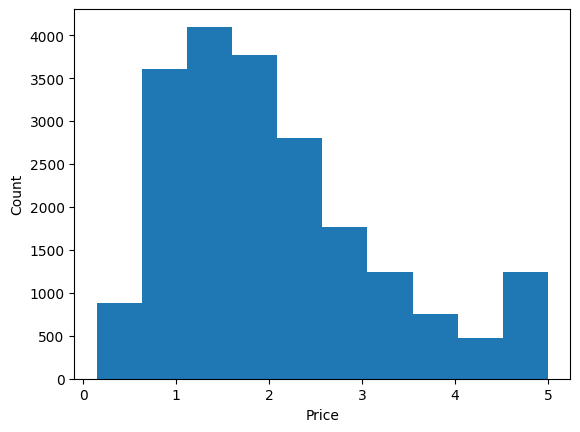

In [26]:
price = housing['target'] # price is a 1D numpy array
plt.hist(price)
plt.xlabel('Price')
plt.ylabel('Count')

### Define X and y for classification tasks

In [27]:
from sklearn import model_selection as ms
X = prep.StandardScaler().fit_transform(data) # X is z-score normalized data

y = (price > 2.5).astype(int) # y value will be 1 if price is higher than a threshold = 2.5 (class-1:high-price), and 0 otherwise (class-0:low-price)


# the following code splits the rows of X randomly into X_train and X_test, and
# the corresponding y into y_train and y_test
# 70% of the data goes into training, and 30% to testing

X_train, X_test, y_train, y_test = ms.train_test_split(X, y, test_size=0.3, random_state=1)

[len(y_train), len(y_test)] # show the number of instances in training and testing

[14448, 6192]

In [28]:
pd.DataFrame(X).describe()

,0,1,2,3,4,5,6,7
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,6.609700e-17,5.508083e-18,6.609700e-17,-1.060306e-16,-1.101617e-17,3.442552e-18,-1.079584e-15,-8.526513e-15
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-1.774299e+00,-2.196180e+00,-1.852319e+00,-1.610768e+00,-1.256123e+00,-2.290000e-01,-1.447568e+00,-2.385992e+00
25%,-6.881186e-01,-8.453931e-01,-3.994496e-01,-1.911716e-01,-5.638089e-01,-6.171062e-02,-7.967887e-01,-1.113209e+00
50%,-1.767951e-01,2.864572e-02,-8.078489e-02,-1.010650e-01,-2.291318e-01,-2.431585e-02,-6.422871e-01,5.389137e-01
75%,4.593063e-01,6.643103e-01,2.519615e-01,6.015869e-03,2.644949e-01,2.037453e-02,9.729566e-01,7.784964e-01
max,5.858286e+00,1.856182e+00,5.516324e+01,6.957171e+01,3.025033e+01,1.194191e+02,2.958068e+00,2.625280e+00


## Task 1. Classification and performance evaluation with logistic regression

### Task 1.1 (8 points) Model training
Provide your code below to train a logistic regression model using X_train and y_train, and show the cofficients of the logistic regression as a horizontal bar chart (barh). Label the plot with feature names.

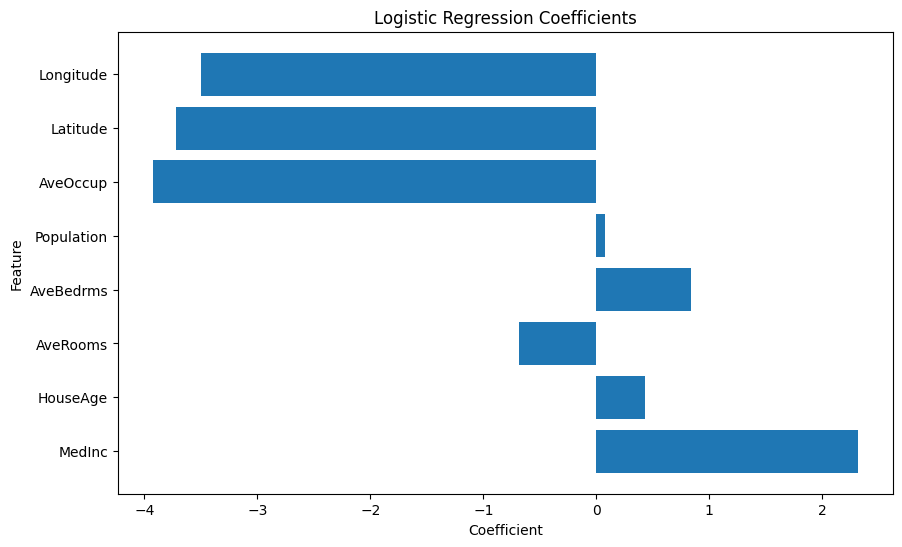

In [29]:
lr = linear_model.LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

coef = lr.coef_.ravel()
feature_names = housing['feature_names']

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coef)
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Logistic Regression Coefficients')
plt.show()

### Task 1.2 (2 points) Model interpretation

Question - based on the plot above, which feature has the most positive contribution towards price and which feature the most negative?

Your answer:The msot feature that has the most positive contribution is MedInc and the most negative is AveOccup

### Task 1.3	(5 pts) Performance on training data
Use the model learned to predict labels for the *training data* and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa. (These functions are available in sklearn.metrics.)

In [30]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, cohen_kappa_score)

y_pred_train = lr.predict(X_train)

cm_train   = confusion_matrix(y_train, y_pred_train)
acc_train  = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, pos_label=1, zero_division=0)
rec_train  = recall_score(y_train, y_pred_train, pos_label=1, zero_division=0)
f1_train   = f1_score(y_train, y_pred_train, pos_label=1, zero_division=0)
kappa_train = cohen_kappa_score(y_train, y_pred_train)

# 3. Output the results
print("Task 1.3 — Performance on Training Data")
print("Confusion Matrix (rows=true, cols=pred):")
print(cm_train)
print(f"Accuracy:  {acc_train:.2f}")
print(f"Precision: {prec_train:.2f}")
print(f"Recall:    {rec_train:.2f}")
print(f"F1 Score:  {f1_train:.2f}")
print(f"Kappa:     {kappa_train:.2f}")


Task 1.3 — Performance on Training Data
Confusion Matrix (rows=true, cols=pred):
[[9654  715]
 [1335 2744]]
Accuracy:  0.86
Precision: 0.79
Recall:    0.67
F1 Score:  0.73
Kappa:     0.63


### Task 1.4 (5 points) Performance on testing data
Use the model learned to predict labels for the *testing data* and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa. (These functions are available in sklearn.metrics if you don’t want to define your own.)

In [31]:
# Step 5: Predict labels for the testing data
y_pred_test = lr.predict(X_test)

# Step 6: Compute performance metrics
cm_test = confusion_matrix(y_test, y_pred_test)
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, pos_label=1, zero_division=0)
rec_test = recall_score(y_test, y_pred_test, pos_label=1, zero_division=0)
f1_test = f1_score(y_test, y_pred_test, pos_label=1, zero_division=0)
kappa_test = cohen_kappa_score(y_test, y_pred_test)

# Step 7: Output the results
print("Task 1.4 — Performance on Testing Data")
print("Confusion Matrix (rows=true, cols=pred):")
print(cm_test)
print(f"Accuracy:  {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall:    {rec_test:.4f}")
print(f"F1 Score:  {f1_test:.4f}")
print(f"Kappa:     {kappa_test:.4f}")

Task 1.4 — Performance on Testing Data
Confusion Matrix (rows=true, cols=pred):
[[4171  318]
 [ 556 1147]]
Accuracy:  0.8589
Precision: 0.7829
Recall:    0.6735
F1 Score:  0.7241
Kappa:     0.6300


### Task 1.5.	(5 pts) 10-fold cross validation
Perform a 10-fold stratified cross-validation and  output the same metrics as required in 1.2: confusion matrix, accuracy, precision, recall, F-1 score and kappa. (Use sklearn.model_selection.cross_val_predict.)

In [32]:
skf = ms.StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
y_cv_pred = ms.cross_val_predict(lr, X, y, cv=skf)

cm_cv = metrics.confusion_matrix(y, y_cv_pred)
acc_cv = metrics.accuracy_score(y, y_cv_pred)
prec_cv = metrics.precision_score(y, y_cv_pred)
rec_cv = metrics.recall_score(y, y_cv_pred)
f1_cv = metrics.f1_score(y, y_cv_pred)
kappa_cv = metrics.cohen_kappa_score(y, y_cv_pred)

# Step 5: Output the results
print("Task 1.5 — 10-fold Cross-validation Performance")
print("Confusion Matrix (rows=true, cols=pred):")
print(cm_cv)
print(f"Accuracy:  {acc_cv:.4f}")
print(f"Precision: {prec_cv:.4f}")
print(f"Recall:    {rec_cv:.4f}")
print(f"F1 Score:  {f1_cv:.4f}")
print(f"Kappa:     {kappa_cv:.4f}")

Task 1.5 — 10-fold Cross-validation Performance
Confusion Matrix (rows=true, cols=pred):
[[13856  1002]
 [ 1831  3951]]
Accuracy:  0.8627
Precision: 0.7977
Recall:    0.6833
F1 Score:  0.7361
Kappa:     0.6441


### Task 1.6	(5 pts) ROC curve and AUC score

Using logistic regression model, perform a 10-fold cross-validation on the entire X and y to get the predicted probabilities with sklearn.model_selection.cross_val_predict, method = 'predict_proba'. Use the returned probability values to plot the ROC curve, and compute the AUC score. Show the AUC score in the bottom-right corner of the ROC plot.

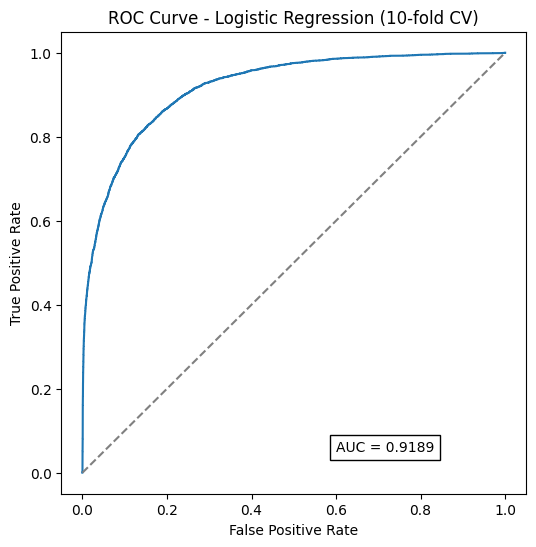

In [33]:
y_cv_proba = ms.cross_val_predict(lr, X, y, cv=skf, method='predict_proba')[:,1]

fpr, tpr, thresholds = metrics.roc_curve(y, y_cv_proba)
auc_score = metrics.auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (10-fold CV)')
plt.text(0.6, 0.05, f"AUC = {auc_score:.4f}", bbox=dict(facecolor='white', edgecolor='black'))
plt.show()

## Task 2. Classification and performance evaluation using decision trees

### Task 2.1 (8 points) Decision tree training
Train a decision tree classifier using X_train and y_train, with parameter max_depth set to 2. Show a figure of the decision tree using sklearn.tree.plot_tree.


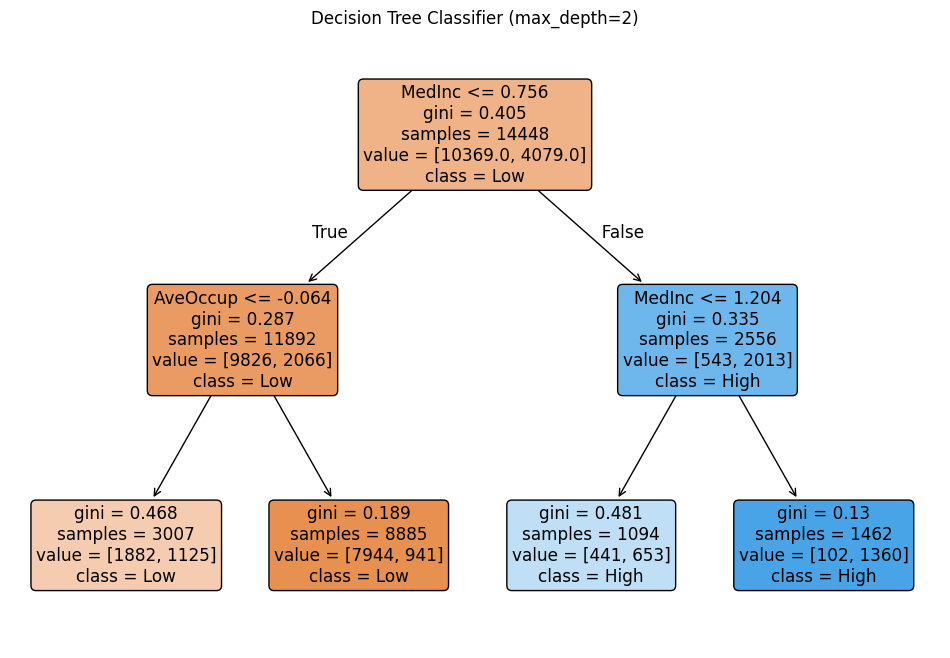

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
dt = DecisionTreeClassifier(random_state=1, max_depth = 2)
dt = dt.fit(X_train, y_train)

# Step 2: Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=feature_names, class_names=['Low', 'High'], filled=True, rounded=True)
plt.title("Decision Tree Classifier (max_depth=2)")
plt.show()

### Task 2.2 (2 points) Model intepretation
For an instance with x[0] = -1 and x[5] = 2, which leaf node (1 - 4, left to right) will be used to classify the instance and what is the predicted label  (class-0:low-price or class-1:high-price)?

Your answer here: class- 0 low and leaf 1. class-2 would be high-price

### Task 2.3 (5 points) Performance on training data

Use the decision tree trained above to predict labels for the training data and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa.

In [44]:
# Step 1: Predict labels for the training data
y_train_pred = dt.predict(X_train)

# Step 4: Compute performance metrics
cm = confusion_matrix(y_train, y_train_pred)
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
kappa = cohen_kappa_score(y_train, y_train_pred)

# Step 5: Print the results
print("Performance on Training Data")
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Kappa: {kappa:.2f}")

Performance on Training Data
Confusion Matrix:
 [[9826  543]
 [2066 2013]]
Accuracy: 0.82
Precision: 0.79
Recall: 0.49
F1 Score: 0.61
Kappa: 0.50


### Task 2.4 (5 points) Performance on testing data

Use the decision tree model trained above to predict labels for the *testing data* and output the following: confusion matrix, accuracy, precision, recall, F-1 score and kappa.

In [53]:
y_test_pred_dt = dt.predict(X_test)

cm_test_dt = metrics.confusion_matrix(y_test, y_test_pred_dt)
acc_test_dt = metrics.accuracy_score(y_test, y_test_pred_dt)
prec_test_dt = metrics.precision_score(y_test, y_test_pred_dt)
rec_test_dt = metrics.recall_score(y_test, y_test_pred_dt)
f1_test_dt = metrics.f1_score(y_test, y_test_pred_dt)
kappa_test_dt = metrics.cohen_kappa_score(y_test, y_test_pred_dt)

print("Performance on Testing Data")
print("Confusion Matrix:\n", cm_test_dt)
print(f"Accuracy: {acc_test_dt:.4f}")
print(f"Precision: {prec_test_dt:.4f}")
print(f"Recall: {rec_test_dt:.4f}")
print(f"F1 Score: {f1_test_dt:.4f}")
print(f"Kappa: {kappa_test_dt:.4f}")

Performance on Testing Data
Confusion Matrix:
 [[4252  237]
 [ 899  804]]
Accuracy: 0.8165
Precision: 0.7723
Recall: 0.4721
F1 Score: 0.5860
Kappa: 0.4768


### Task 2.5 (8 points). Expriment to study overfitting

Now construct a series of decision trees (using a for loop) with max_depth set to 1, 2, 3, ..., 25. Use each decision tree to predict labels for the training data and test data, and record the corresponding f1-scores. Make a line graph between the max_depth (x-axis) and F-1 scores (y-axis). Label your figures, and use legend to show which line is for training data and which line is for testing data.

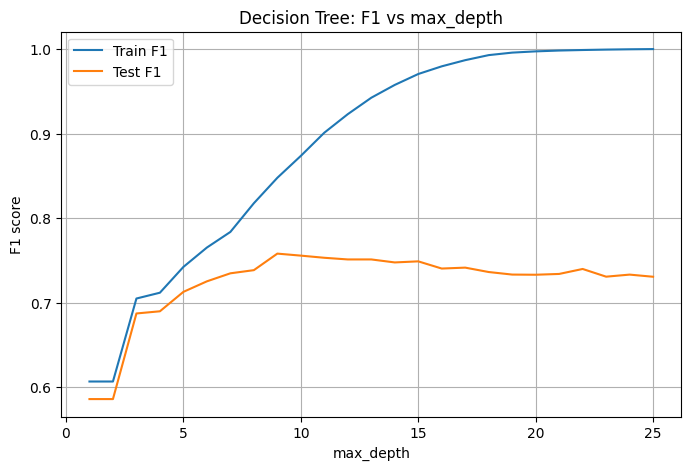

In [57]:
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Step 2: Initialize lists to store F1 scores
train_f1_scores = []
test_f1_scores = []

# Step 3: Loop through max_depth from 1 to 25
for max_depth in range(1, 26):
    dt = DecisionTreeClassifier(random_state=1, max_depth=max_depth)
    dt.fit(X_train, y_train)
    train_f1_scores.append(f1_score(y_train, dt.predict(X_train)))
    test_f1_scores.append(f1_score(y_test, dt.predict(X_test)))


# Step 4: Plot the results
plt.figure(figsize=(8,5))
plt.plot(range(1, 26), train_f1_scores, label='Train F1')
plt.plot(range(1, 26), test_f1_scores, label='Test F1')
plt.xlabel('max_depth')
plt.ylabel('F1 score')
plt.title('Decision Tree: F1 vs max_depth')
plt.legend()
plt.grid(True)
plt.show()

TypeError: unsupported operand type(s) for /: 'list' and 'int'

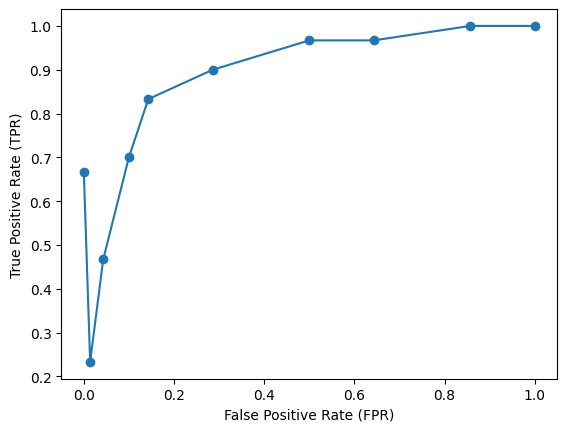

In [67]:
import matplotlib.pyplot as plt

# Data: TPR and FPR
fpr = [0, 0.014, 0.043, 0.1, 0.143, 0.286, 0.5, 0.643, 0.857, 1]
tpr = [0.667, 0.233, 0.467, 0.7, 0.833, 0.9, 0.967, 0.967, 1, 1]

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, marker='o')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')

 diff(fpr).dot(tpr[1:]+tpr[:-1])/2.)
# Adding labels and title

plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.grid()

# Show the plot
plt.show()

### Task 2.6 (2 points) Question
Based on the figure above, at approximately what max-depth value did the algorithm start over-fitting the data and why?

Your answer here:5 is where it is starting to overfiing the data and the reason is because F1 is continuing to increase while testing f1 is decreasing.

## Task 3: (Bonus 10 points) Ensemble classifier

Train a Random Forest Classifier using X_train and y_train, use it to make predictions on X_test and print out the the Precision, Recall, and F-1 score. Repeat for Gradient Boosting Classifier. Use n_estimator = 100.
(For your satisfaction: compare their F-1 score with Logistic Regression and Decision Tree classifiers.)

In [64]:
rf = ensemble.RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(X_train, y_train)
y_test_pred_rf = rf.predict(X_test)
print("Random Forest -- Precision:", metrics.precision_score(y_test, y_test_pred_rf),
      "Recall:", metrics.recall_score(y_test, y_test_pred_rf),
      "F1:", metrics.f1_score(y_test, y_test_pred_rf))

# Gradient Boosting
gb = ensemble.GradientBoostingClassifier(n_estimators=100, random_state=1)
gb.fit(X_train, y_train)
y_test_pred_gb = gb.predict(X_test)
print("Gradient Boosting -- Precision:", metrics.precision_score(y_test, y_test_pred_gb),
      "Recall:", metrics.recall_score(y_test, y_test_pred_gb),
      "F1:", metrics.f1_score(y_test, y_test_pred_gb))


Random Forest -- Precision: 0.8692411924119241 Recall: 0.7533763945977686 F1: 0.8071720666876376
Gradient Boosting -- Precision: 0.8509933774834437 Recall: 0.7545507927187316 F1: 0.7998755057578587
